## Connectivity
--> does not suffer from alignment problems..?!

- Parcel-Space! --> getCM_parcel

- Correlate Vis2-dorsalAtt-FC-strength with NPC-dispersion & Vis2-dorsalAtt-BN-dispersion...



In [4]:
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
import pandas as pd

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'
bids_folder_orig = '/mnt_03/ds-dnumrisk' 

subList = [f'{int(sub):02d}' for sub in range(1, 67)]
sub_array = range(1, 67)

# add group info
df_participants = pd.read_csv(op.join(bids_folder_orig, 'add_tables','subjects_recruit_scan_scanned-final.csv'), header=0) #, index_col=0
group_list = df_participants.loc[:,['subject ID','group']].rename(mapper={'subject ID': 'subject'},axis=1).dropna().astype({'subject': int, 'group': int}).set_index('subject')

In [5]:
from numrisk.fmri_analysis.gradients.utils import get_glasser_parcels, get_glasser_CAatlas_mapping
mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

In [44]:
confspec = 'oldConfounds'

subList = [f'{int(sub):02d}' for sub in range(1, 67)]
sub_array = np.array([int(i) for i in subList])

source_folder = op.join(bids_folder_orig, 'derivatives', 'correlation_matrices')
CMs= [None] * len(subList)

for i,sub in enumerate(subList):
    cm_file = op.join(source_folder,f'sub-{sub}_glasserParcel-fsaverage.npy')
    cm = np.load(cm_file)
    CMs[i] = cm

CMs = np.array(CMs)
np.shape(CMs)

(66, 360, 360)

In [ ]:
confspec = '32Pscrub3BPfilter'
only_top10 = True
top_n = 36

subList = [f'{int(sub):02d}' for sub in range(1, 67)]
# outliers for GMs-aligend ~ for 32P: sub-6; for 36P: sub-64
subList.remove('64') if confspec == '36Pscrub3BPfilter' else subList.remove('06') 
sub_array = np.array([int(i) for i in subList])

source_folder = op.join(bids_folder, 'derivatives', 'correlation_matrices.parcel')
CMs= [None] * len(subList)

for i,sub in enumerate(subList):
    cm_file = op.join(source_folder,f'sub-{sub}_glasserParcel-fsaverage_confspec-{confspec}.npy')
    cm = np.load(cm_file)
    if only_top10:
        cm_c = np.zeros_like(cm)
        for ii,row in enumerate(cm): 
            top_10_ind = np.argsort(row)[-top_n:][::-1] # argsort returns indices of sorted array in ascending order, [-top_n:] takees therefore the top (here=last) 36, [::-1] reverses the array
            cm_c[ii, top_10_ind] = row[top_10_ind]
        CMs[i] = cm_c
    else:
        CMs[i] = cm

CMs = np.array(CMs)
np.shape(CMs)

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 21)

In [8]:
sub = subList[0]
only_top10 = True
top_n = 36 # 10% * 360

cm_file = op.join(source_folder,f'sub-{sub}_glasserParcel-fsaverage_confspec-{confspec}.npy')
cm = np.load(cm_file)
if only_top10:
        cm_c = np.zeros_like(cm)
        for i,row in enumerate(cm): 
            top_10_ind = np.argsort(row)[-top_n:][::-1] # argsort returns indices of sorted array in ascending order, [-top_n:] takees therefore the top (here=last) 36, [::-1] reverses the array
            cm_c[i, top_10_ind] = row[top_10_ind]
    #CMs[i] = np.array([row[top_10_ind] for row in cm])

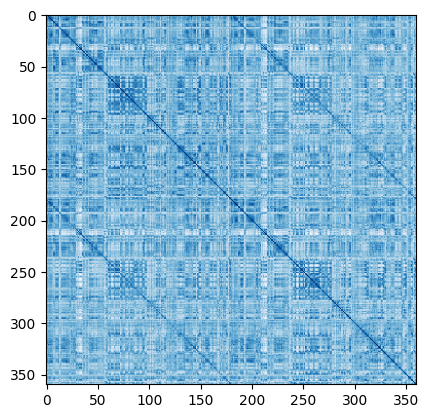

In [11]:
import matplotlib.pyplot as plt
plt.imshow(cm, cmap='Blues')

In [45]:
from scipy.stats import ttest_ind
N_nets = 12

mat_tstat = np.zeros([N_nets, N_nets])
mat_pvals = np.ones([N_nets, N_nets])
average_mean_BN_fc_strength = np.zeros([N_nets, N_nets])
for seed_net in np.unique(glasser_CAatlas_mapping['ca_network']):
    for target_net in np.unique(glasser_CAatlas_mapping['ca_network']):
        network_seed_indices = np.where(glasser_CAatlas_mapping['ca_network'] == seed_net)[0]
        network_target_indices = np.where(glasser_CAatlas_mapping['ca_network'] == target_net)[0]

        mean_BN_fc_strength = []
        for i,sub in enumerate(subList):
            cm = CMs[i]
            cm_fil = cm[np.ix_(network_seed_indices, network_target_indices)]
            #fc_cm_fil = np.mean(cm_fil,axis=1)
            mean_fc_cm_fil = np.mean(np.mean(cm_fil,axis=1)) 
            mean_BN_fc_strength.append(mean_fc_cm_fil)
        average_mean_BN_fc_strength[seed_net-1,target_net-1] = np.mean(mean_BN_fc_strength)
        
        df = pd.DataFrame(np.array(mean_BN_fc_strength), index=sub_array)
        df.index.name = 'subject'
        df = df.join(group_list).set_index('group',append=True)
        t_stat, p_val = ttest_ind(df.xs(0,0,'group'), df.xs(1,0,'group'), equal_var=False)  # Welch's t-test

        mat_tstat[seed_net-1,target_net-1] = t_stat[0]
        mat_pvals[seed_net-1,target_net-1] = np.round(p_val, 3)



/tmp/ipykernel_93400/345769948.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat_pvals[seed_net-1,target_net-1] = np.round(p_val, 3)
/tmp/ipykernel_93400/345769948.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat_pvals[seed_net-1,target_net-1] = np.round(p_val, 3)
/tmp/ipykernel_93400/345769948.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat_pvals[seed_net-1,target_net-1] = np.round(p_val, 3)
/tmp/ipykernel_93400/345769948.py:27: Deprecation

Text(0.5, 1.1, 'Average Between network FC strength \n oldConfounds')

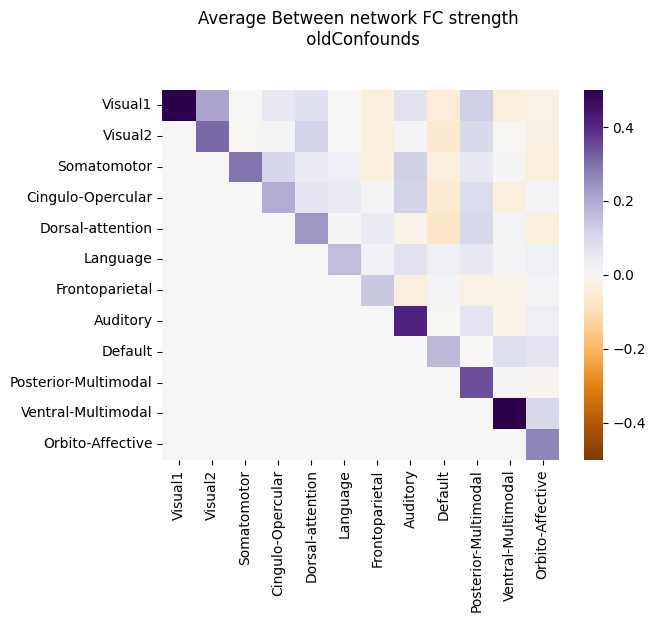

In [46]:
average_mean_BN_fc_strength[np.tril_indices_from(average_mean_BN_fc_strength, k=-1)] = 0

sns.heatmap(average_mean_BN_fc_strength, vmin=-.5,vmax=.5,cmap=  'PuOr',# 'bwr',
            xticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)],
            yticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)])
plt.title(f'Average Between network FC strength \n {confspec}' , y=1.1)

Text(0.5, 1.1, 'Between network FC strength (T-stat) \n oldConfounds')

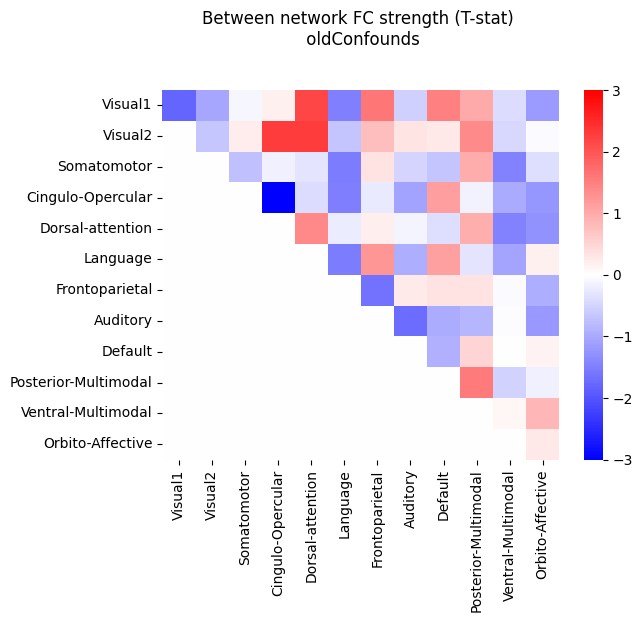

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

mat_tstat_ = mat_tstat.copy()
mat_tstat_[np.tril_indices_from(mat_tstat, k=-1)] = 0

sns.heatmap(mat_tstat_, cmap='bwr',vmin=-3,vmax=3,
            xticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)],
            yticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)])
plt.title(f'Between network FC strength (T-stat) \n {confspec}' , y=1.1)

Text(0.5, 1.02, 'P-vals of between group TTEst on between network FC strength \n 32Pscrub3BPfilter')

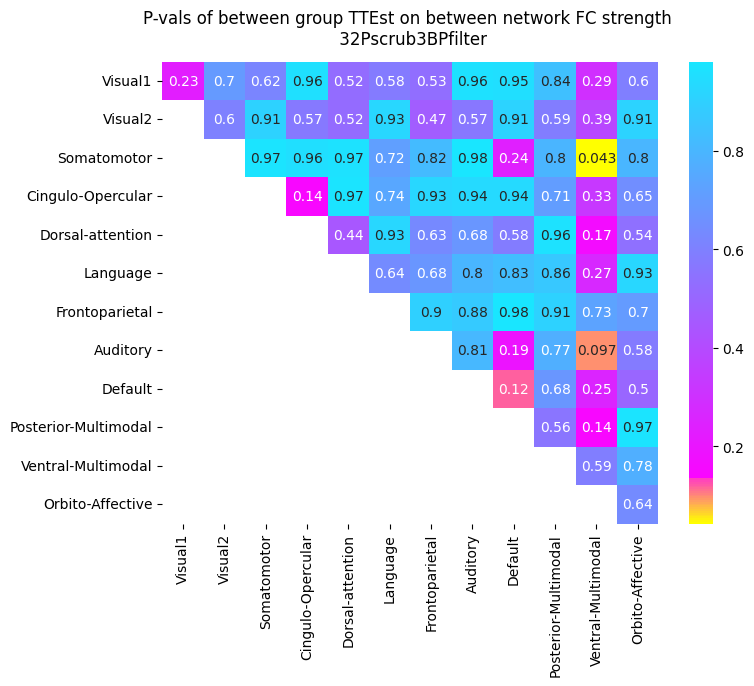

In [42]:
from numrisk.fmri_analysis.gradients.utils_02 import get_pval_colormap

pval_cmap = get_pval_colormap()

mat_pvals_ = mat_pvals.copy()
mat_pvals_[np.tril_indices_from(mat_pvals_, k=-1)] = np.nan

fig, axes = plt.subplots(1,1, figsize=(8,6)) 
sns.heatmap(mat_pvals_, cmap=pval_cmap,annot=True,ax=axes,#vmin=-0.4,vmax=0.4,
            xticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)],
            yticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)])
plt.title(f'P-vals of between group TTEst on between network FC strength \n {confspec}', y=1.02)

In [24]:
network_2_indices = np.where(glasser_CAatlas_mapping['ca_network'] == 2)[0]
network_5_indices = np.where(glasser_CAatlas_mapping['ca_network'] == 5)[0]

mean_fc_vis_dorat_strengths = []
for sub in subList:
    cm_file = op.join(source_folder,f'sub-{sub}_glasserParcel-fsaverage_confspec-{confspec}.npy')
    cm = np.load(cm_file)

    cm_vis_dorat = cm[np.ix_(network_2_indices, network_5_indices)]
    fc_vis_dorat_strength = np.mean(cm_vis_dorat,axis=1)
    mean_fc_vis_dorat_strength = np.mean(fc_vis_dorat_strength) 
    mean_fc_vis_dorat_strengths.append(mean_fc_vis_dorat_strength)


sub_array = np.array([int(i) for i in subList])
df = pd.DataFrame(np.array(mean_fc_vis_dorat_strengths), index=sub_array, columns=['mean_fc_vis_dorat_strength'])
df.index.name = 'subject'
df = df.join(group_list).set_index('group',append=True)


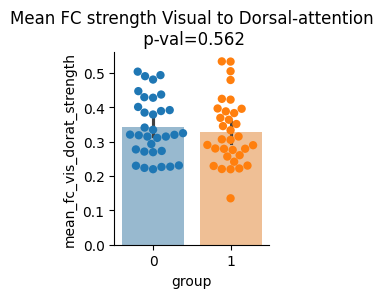

In [25]:
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

y_var = 'mean_fc_vis_dorat_strength' #  'NPC_centroid'

tmp = df.copy()

figure, axes = plt.subplots(1, 1,figsize = (2,2.5))
sns.barplot(data=tmp.reset_index(), x ='group', hue='group',y=y_var, alpha=0.5,legend=False)
sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=6,legend=False)
t_stats, p_values = ttest_ind(tmp.xs(0,0,'group')[y_var], tmp.xs(1,0,'group')[y_var], axis=0, equal_var=False)
p_val = np.round(p_values,3)

axes.set(title=f'Mean FC strength Visual to Dorsal-attention\n p-val={p_val}',ylabel=y_var, xlabel='group')
sns.despine()